# 02 · Stance over time — the spine

How does pro/anti/neutral stance evolve, and does it **inflect at the Jan 5 2025
launch**? We use two complementary readouts:

- **100%-stacked share** — the full composition (what fraction is pro/anti/neutral).
- **Net stance index** = `share_pro − share_anti` (range −1…+1). One line; >0 means
  net-favorable. We also show the **soft** version (mean `p_pro − p_anti`).

Plotted at **daily → weekly → monthly** so you can see both event-level spikes
and the slow trend. Stats: an **interrupted time series** at the launch.

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
sh = A.load_rollup("stance_hourly")
sh = A.add_geo(sh)
ONTOPIC = ["anti","neutral","pro"]

def stance_over_grain(grain):
    """Overall on-topic stance shares + net index at a time grain."""
    agg = A.aggregate(sh, grain, by=(), stance_col="stance")   # period x stance
    wide = A.stance_shares(agg, index_cols=["period"])
    wide = wide.sort_values("period")
    lo, hi = A.net_ci(wide.share_pro, wide.share_anti, wide.n_total)
    wide["net_lo"], wide["net_hi"] = lo, hi
    return wide
monthly = stance_over_grain("monthly")
monthly.tail(4)[["period","n_total","share_anti","share_neutral","share_pro","net"]]

stance,period,n_total,share_anti,share_neutral,share_pro,net
37,2026-01-01,3280,0.275610,0.147561,0.576829,0.301220
38,2026-02-01,1602,0.312110,0.128589,0.559301,0.247191
39,2026-03-01,2783,0.355013,0.113187,0.531800,0.176788
40,2026-04-01,1993,0.302057,0.081786,0.616157,0.314099


### Composition: 100%-stacked share (monthly)

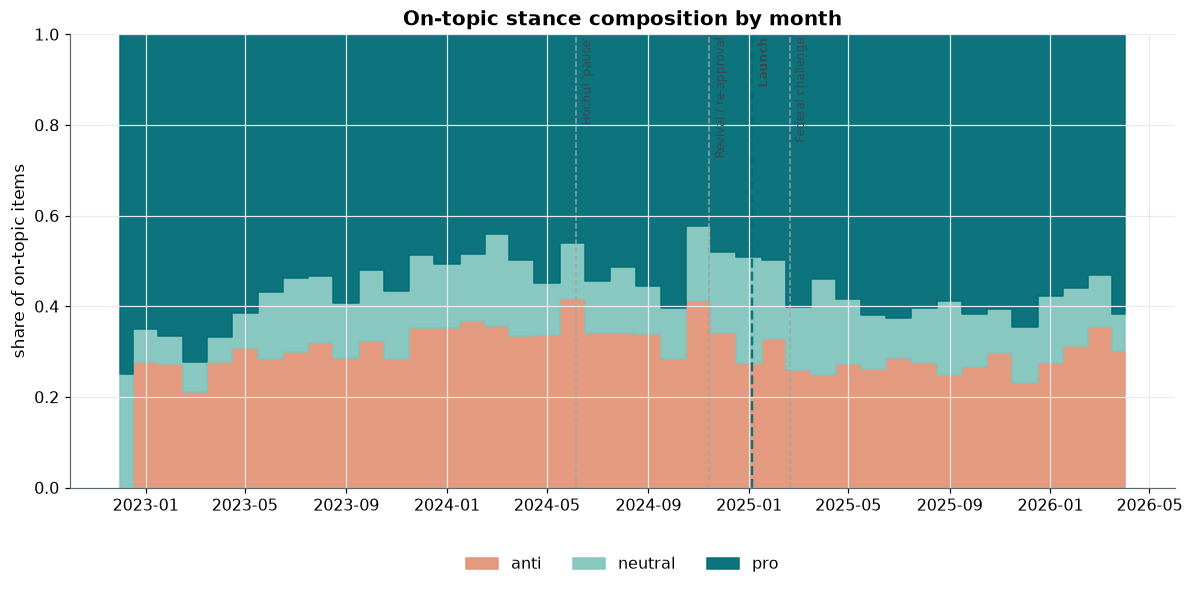

In [3]:
fig, ax = plt.subplots()
A.stacked_share(ax, monthly, "period", title="On-topic stance composition by month")
A.annotate_events(ax)
plt.tight_layout(); plt.show()

### Net stance index across the three grains

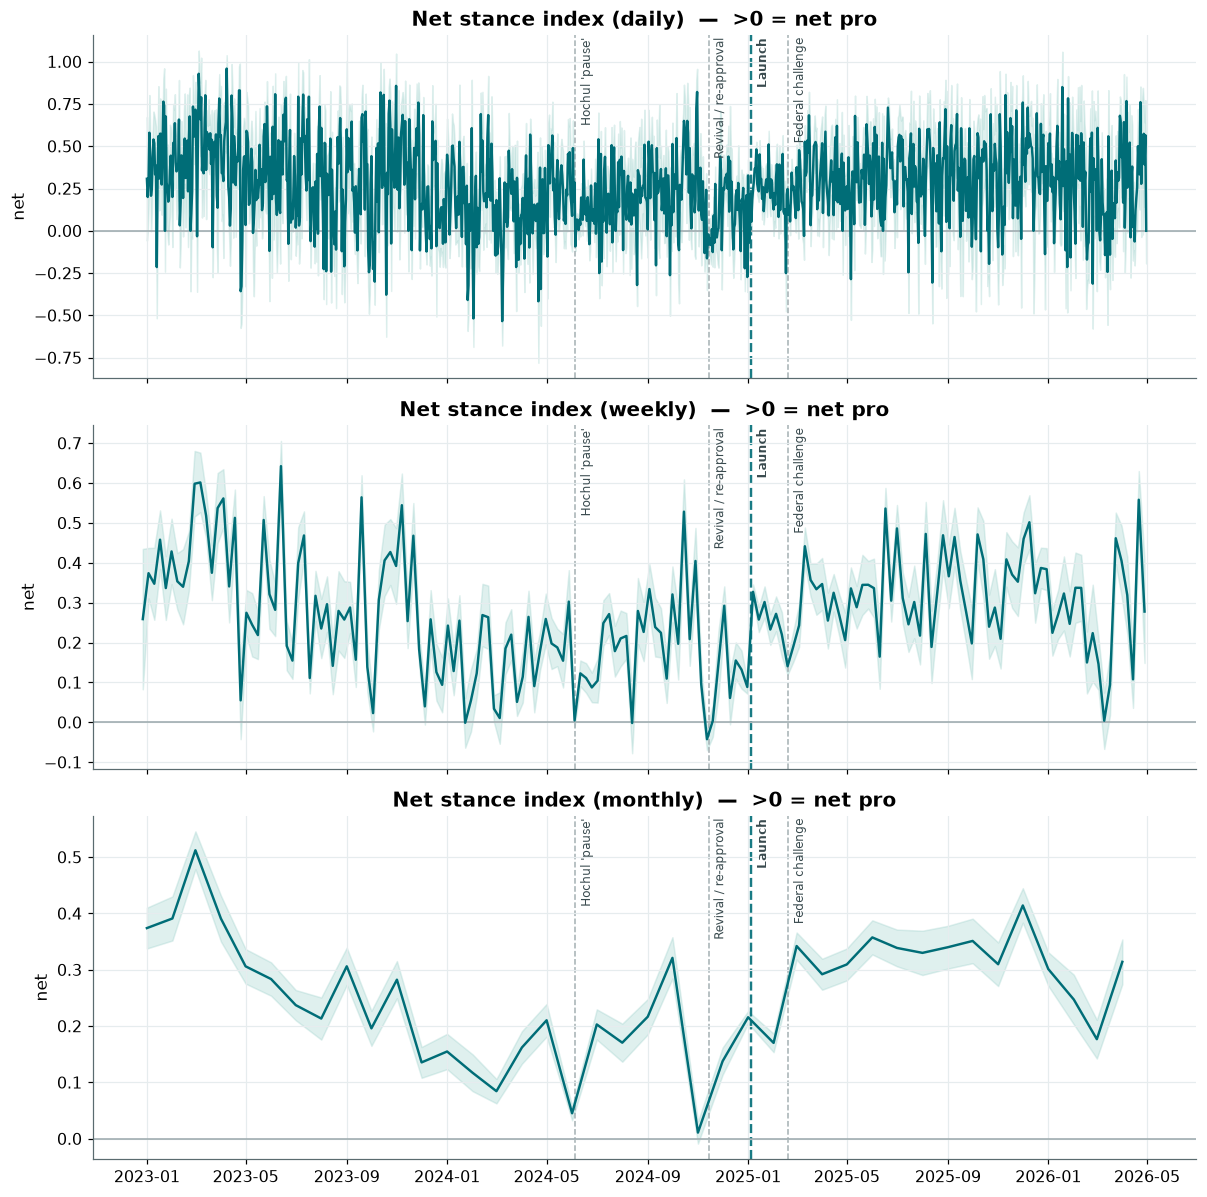

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, grain in zip(axes, ["daily","weekly","monthly"]):
    w = stance_over_grain(grain)
    w = w[w.n_total >= (5 if grain=="daily" else C.MIN_N)]
    ax.axhline(0, color="#9AA7AB", lw=1)
    ax.fill_between(w.period, w.net_lo, w.net_hi, color=C.PALETTE["teal"], alpha=0.25)
    ax.plot(w.period, w.net, color=C.PALETTE["deep_teal"], lw=1.6)
    ax.set_title(f"Net stance index ({grain})  —  >0 = net pro"); ax.set_ylabel("net")
    A.annotate_events(ax)
plt.tight_layout(); plt.show()

### Hard vs soft net index

The **soft** index uses class probabilities (confidence-weighted), so a comment
the model is 55% sure is pro counts less than one it's 99% sure about. If the two
lines agree, the argmax counts aren't hiding anything.

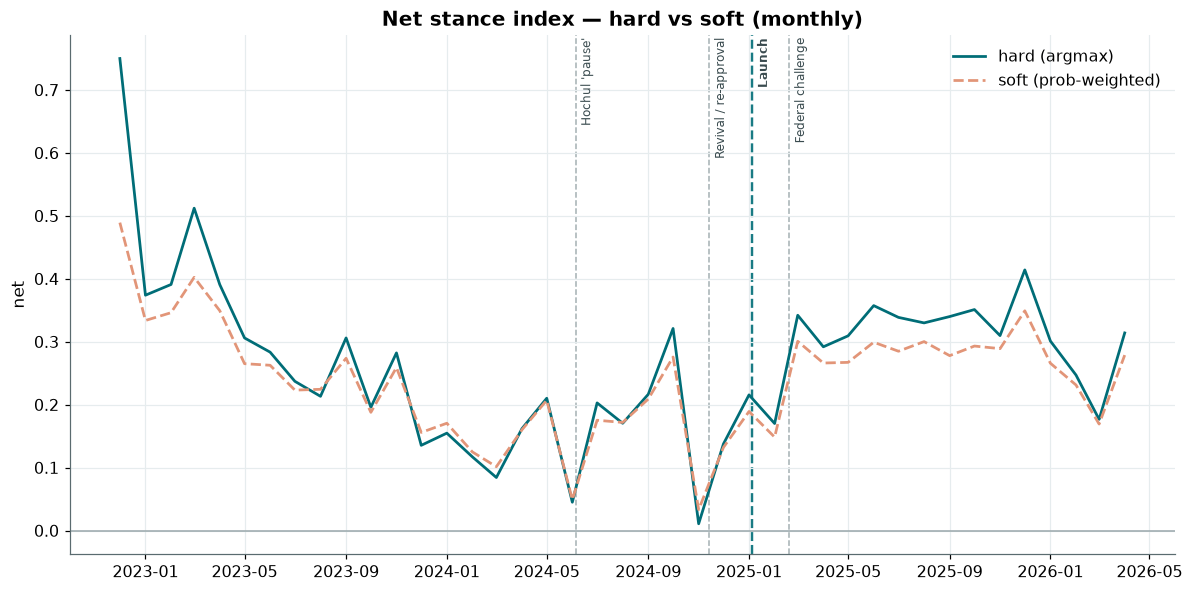

In [5]:
soft = A.load_rollup("stance_soft_hourly")
soft["period"] = A.time_bucket(soft.et_date, "monthly")
sa = soft.groupby("period").sum(numeric_only=True)
on = sa[["sum_p_anti","sum_p_neutral","sum_p_pro"]].sum(axis=1)
soft_net = (sa["sum_p_pro"] - sa["sum_p_anti"]) / on

fig, ax = plt.subplots()
ax.axhline(0, color="#9AA7AB", lw=1)
ax.plot(monthly.period, monthly.net, color=C.PALETTE["deep_teal"], lw=1.8, label="hard (argmax)")
ax.plot(soft_net.index, soft_net.values, color=C.PALETTE["terracotta"], lw=1.8, ls="--", label="soft (prob-weighted)")
ax.set_title("Net stance index — hard vs soft (monthly)"); ax.set_ylabel("net"); ax.legend()
A.annotate_events(ax)
plt.tight_layout(); plt.show()

### Statistical test — interrupted time series at the launch

Segmented regression on the monthly net index: fit a level + trend, then estimate
a **level shift** and **trend change** at Jan 5 2025. Weighted by monthly n.
A significant `post` coefficient = an immediate jump at launch; a significant
`post:months_since` = a change in the ongoing trend.

In [6]:
import statsmodels.api as sm
launch = pd.Timestamp(C.EVENTS[[e["primary"] for e in C.EVENTS].index(True)]["date"])
d = monthly.dropna(subset=["net"]).copy()
d["t"] = (d.period.dt.year - d.period.dt.year.min())*12 + d.period.dt.month
d["t"] = d["t"] - d["t"].min()
d["post"] = (d.period >= launch).astype(int)
tl = d.loc[d.period >= launch, "t"].min()
d["since"] = (d["t"] - tl).clip(lower=0) * d["post"]
X = sm.add_constant(d[["t","post","since"]])
res = sm.WLS(d["net"], X, weights=d["n_total"]).fit()
print(res.summary().tables[1])
print("\nInterpretation:")
print(f"  level shift at launch (post): {res.params['post']:+.3f}  p={res.pvalues['post']:.3g}")
print(f"  trend change (post:since)   : {res.params['since']:+.4f}/mo  p={res.pvalues['since']:.3g}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3038      0.045      6.766      0.000       0.213       0.395
t             -0.0077      0.002     -3.079      0.004      -0.013      -0.003
post           0.1528      0.050      3.031      0.004       0.051       0.255
since          0.0129      0.006      2.004      0.052      -0.000       0.026

Interpretation:
  level shift at launch (post): +0.153  p=0.00443
  trend change (post:since)   : +0.0129/mo  p=0.0524


### Off-topic share over time — a relevance / salience check

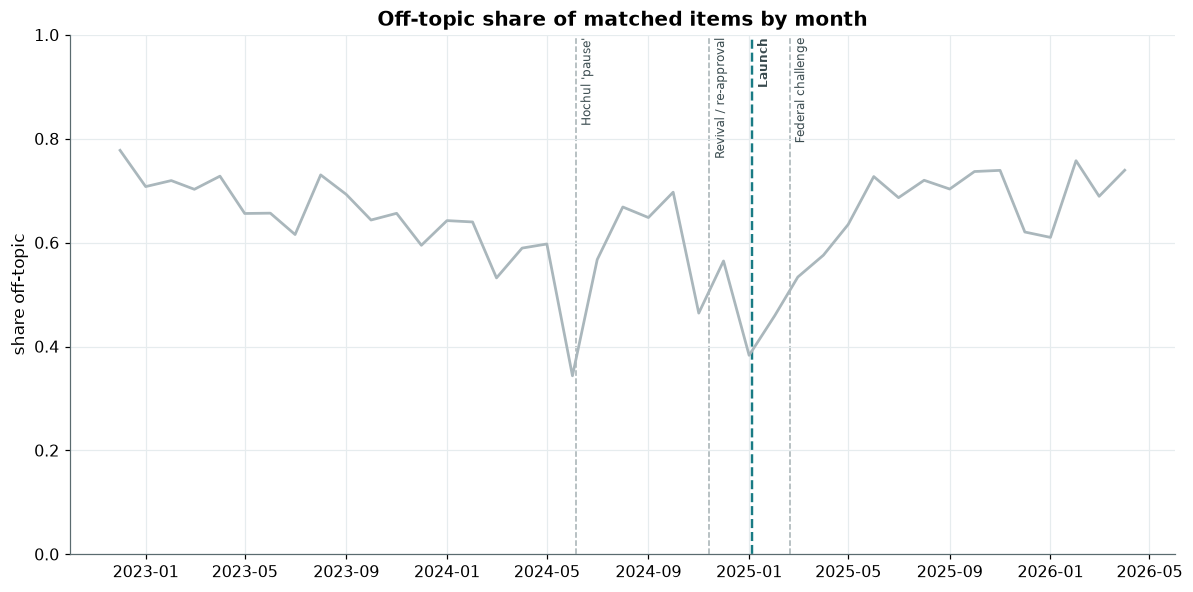

In [7]:
allc = A.aggregate(sh, "monthly", by=(), stance_col="stance")
tot = allc.groupby("period")["n"].sum()
off = allc[allc.stance=="off-topic"].set_index("period")["n"] / tot
fig, ax = plt.subplots()
ax.plot(off.index, off.values, color=C.STANCE_COLORS["off-topic"], lw=1.8)
ax.set_ylim(0,1); ax.set_title("Off-topic share of matched items by month"); ax.set_ylabel("share off-topic")
A.annotate_events(ax)
plt.tight_layout(); plt.show()

**Takeaways to write up:** direction of the net index pre vs post launch, whether
the ITS level/trend terms are significant, whether hard & soft agree, and whether
off-topic share moves (a drop near events = the filter is catching real signal).

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>